<a href="https://colab.research.google.com/github/Tamararoa/Aprendizaje_Automatico/blob/main/Clase4_Act1_RL_TamaraRoa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Actividad: Modelado Regresion Lineal

Este proyecto es analizar y modelar la relación lineal entre la Cantidad de Kilogramos comercializados (cantidad_de_kg) y el Precio por Kilogramo Vivo (precio($)_kg_vivo) de ganado vacuno.

A través de un modelo de Regresión Lineal Simple, se busca:
Evaluar el impacto de la cantidad comercializada sobre la fijación del precio por kilo vivo.
Determinar los parámetros del modelo (pendiente $m$ e intersección $b$) para estimar la variación marginal del precio.Generar un modelo predictivo capaz de estimar el precio esperado por kilogramo vivo según el volumen de hacienda transaccionado.

1-Importacion de liberias y carga data set

In [6]:
# Importación de librerías para manipulación de datos, gráficos y modelado
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    explained_variance_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import train_test_split

# Estilo gráfico general
sns.set_theme(style="whitegrid")

# Carga del dataset SIO Carnes
df = pd.read_csv('SIO_CARNES.csv', encoding='utf-8-sig')

# Visualizamos las primeras filas
df.head()

,_id,pais_id,pais,provincia_origen_id,provincia_origen,departamento_origen_id,departamento_origen,zona_destino,fecha_comprobante,raza,categoria,cabezas_comercializadas,Unidad de Medida,precio($)_cabeza,precio($)_kg_vivo,cantidad_de_kg
0,1,32,Argentina,30,Entre Rios,56,Gualeguaychu,ZONA 2,2018-01-01T00:00:00,Aberdeen Angus,Bovino Novillitos Regulares,7,Kg. Vivo,NaN,20.00,2190.0
1,2,32,Argentina,30,Entre Rios,56,Gualeguaychu,ZONA 2,2018-01-01T00:00:00,Aberdeen Angus,Bovino Vaquillona Regulares,11,Kg. Vivo,NaN,20.00,3300.0
2,3,32,Argentina,6,Buenos Aires,175,Colon,ZONA 2,2018-01-01T00:00:00,Aberdeen Angus,Bovino Terneras hasta 350 kilos,7,Kg. Vivo,NaN,26.90,2426.0
3,4,32,Argentina,6,Buenos Aires,175,Colon,ZONA 2,2018-01-01T00:00:00,Aberdeen Angus,Bovino Terneros hasta 350 kilos,7,Kg. Vivo,NaN,26.90,2429.0
4,5,32,Argentina,6,Buenos Aires,651,Puan,ZONA 6,2018-01-01T00:00:00,Aberdeen Angus,Bovino Novillos Especiales y Buenos 461/490 kilos,10,Kg. Vivo,NaN,29.06,4811.0


2-Exploración y Limpieza Inicial

In [7]:
# Verificación de dimensiones, nulos y tipos de datos
df.info()

# Verificación de duplicados
print(f"Filas duplicadas: {df.duplicated().sum()}")

# Resumen estadístico de variables clave
df[['cantidad_de_kg', 'precio($)_kg_vivo']].describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   _id                      250 non-null    int64  
 1   pais_id                  250 non-null    int64  
 2   pais                     250 non-null    object 
 3   provincia_origen_id      250 non-null    int64  
 4   provincia_origen         250 non-null    object 
 5   departamento_origen_id   250 non-null    int64  
 6   departamento_origen      250 non-null    object 
 7   zona_destino             250 non-null    object 
 8   fecha_comprobante        250 non-null    object 
 9   raza                     250 non-null    object 
 10  categoria                250 non-null    object 
 11  cabezas_comercializadas  250 non-null    int64  
 12  Unidad de Medida         250 non-null    object 
 13  precio($)_cabeza         30 non-null     float64
 14  precio($)_kg_vivo        2

,cantidad_de_kg,precio($)_kg_vivo
count,220.000000,220.000000
mean,7229.022727,29.181227
std,6145.498148,5.749558
min,192.000000,14.000000
25%,1624.750000,26.000000
50%,5556.000000,29.000000
75%,12017.750000,32.100000
max,27727.000000,49.750000


3-Análisis Exploratorio de Datos (EDA)

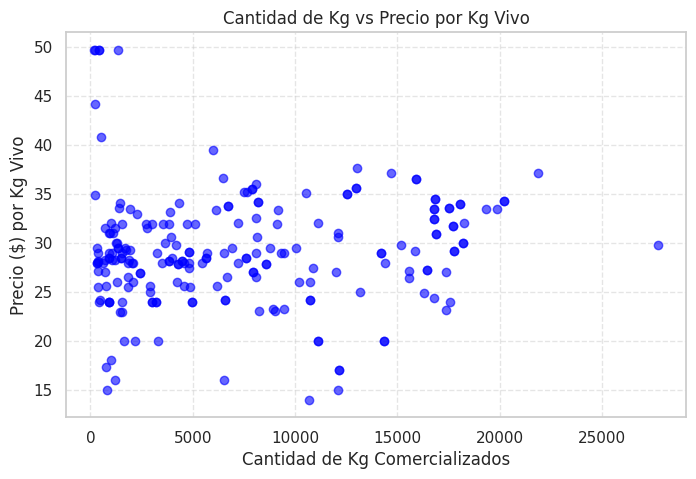

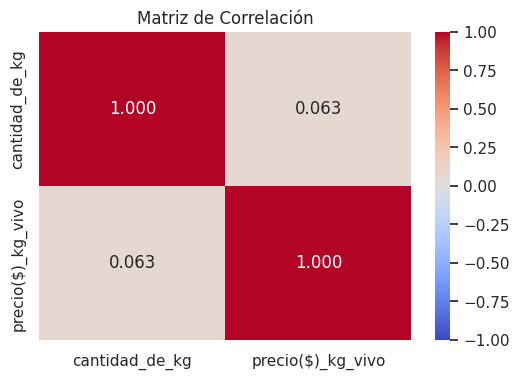

In [15]:
# Gráfico de Dispersión
plt.figure(figsize=(8, 5))
plt.scatter(df['cantidad_de_kg'], df['precio($)_kg_vivo'], color='blue', alpha=0.6)
plt.title('Cantidad de Kg vs Precio por Kg Vivo')
plt.xlabel('Cantidad de Kg Comercializados')
plt.ylabel('Precio ($) por Kg Vivo')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Matriz de Correlación
plt.figure(figsize=(6, 4))
sns.heatmap(
    df[['cantidad_de_kg', 'precio($)_kg_vivo']].corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".3f",
    vmin=-1,
    vmax=1,
)
plt.title('Matriz de Correlación')
plt.show()

4-Selección de Variables y División Entrenamiento / Prueba

In [10]:
# 1. Selección y filtrado de datos nulos
df_model = df[['cantidad_de_kg', 'precio($)_kg_vivo']].dropna()

X = df_model[['cantidad_de_kg']]  # Matriz 2D
y = df_model['precio($)_kg_vivo']  # Vector 1D

# 2. División en conjuntos de Train / Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Muestras de entrenamiento: {X_train.shape[0]}")
print(f"Muestras de prueba: {X_test.shape[0]}")

Muestras de entrenamiento: 176
Muestras de prueba: 44


5-Entrenamiento del Modelo y Evaluación

In [11]:
# Entrenamiento
model = LinearRegression()
model.fit(X_train, y_train)

# Predicciones
y_pred = model.predict(X_test)

# Métricas de Evaluación
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
var_exp = explained_variance_score(y_test, y_pred)

print(f"Intercepto (b): {model.intercept_:.4f}")
print(f"Coeficiente (m): {model.coef_[0]:.6f}\n")

print("Evaluación del modelo (Regresión Lineal Simple):")
print(f"MAE (Error Absoluto Medio): {mae:.3f}")
print(f"MSE (Error Cuadrático Medio): {mse:.3f}")
print(f"RMSE (Raíz del Error Cuadrático Medio): {rmse:.3f}")
print(f"R² (Coeficiente de Determinación): {r2:.3f}")
print(f"Varianza Explicada: {var_exp:.3f}")

Intercepto (b): 28.6494
Coeficiente (m): 0.000071

Evaluación del modelo (Regresión Lineal Simple):
MAE (Error Absoluto Medio): 4.160
MSE (Error Cuadrático Medio): 34.937
RMSE (Raíz del Error Cuadrático Medio): 5.911
R² (Coeficiente de Determinación): -0.004
Varianza Explicada: -0.004


6-Análisis de Residuos

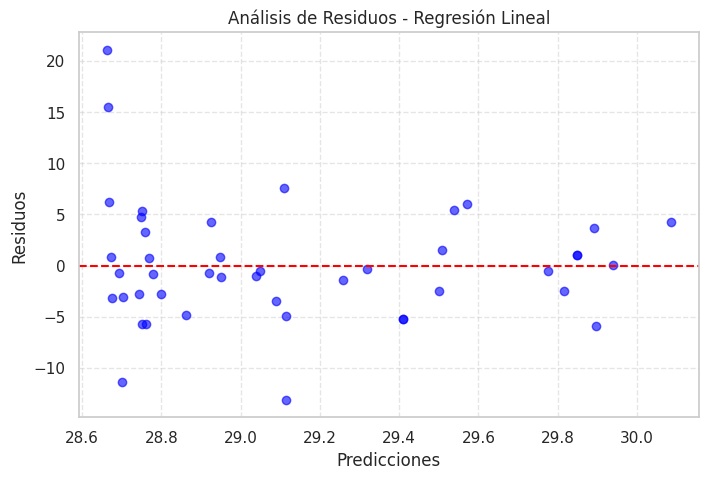

In [12]:
residuos = y_test - y_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuos, color='blue', alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicciones")
plt.ylabel("Residuos")
plt.title("Análisis de Residuos - Regresión Lineal")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

7-Gráfico de Ajuste del Modelo (Valores Reales vs Predichos)

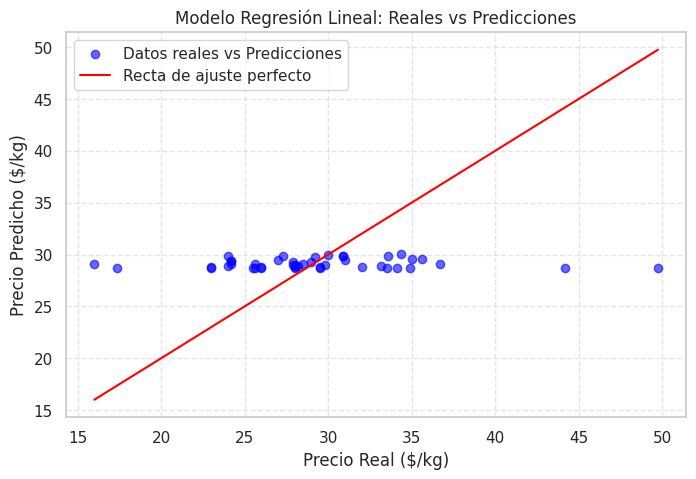

In [13]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, label="Datos reales vs Predicciones", color='blue', alpha=0.6)

# Línea de ajuste perfecto (diagonal)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', label="Recta de ajuste perfecto")

plt.xlabel("Precio Real ($/kg)")
plt.ylabel("Precio Predicho ($/kg)")
plt.title("Modelo Regresión Lineal: Reales vs Predicciones")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

8-Interpretación de Coeficientes e Inferencia de Negocio

In [14]:
print(f"Intercepto (b): {model.intercept_:.3f}")
print(f"Precio base estimado sin considerar volumen: ${model.intercept_:.2f} / kg vivo\n")

print(f"Coeficiente cantidad_de_kg (m): {model.coef_[0]:.6f}")
print(f"-> Por cada 1,000 kg adicionales comercializados, el precio por kg vivo varía en ${model.coef_[0] * 1000:.2f}.\n")

Intercepto (b): 28.649
Precio base estimado sin considerar volumen: $28.65 / kg vivo

Coeficiente cantidad_de_kg (m): 0.000071
-> Por cada 1,000 kg adicionales comercializados, el precio por kg vivo varía en $0.07.



9-Observaciones y Conclusión de Negocio:

Pendiente casi nula ($m \approx 0$):
El coeficiente del modelo indica que por cada $1.000\text{ kg}$ adicionales comercializados, el precio esperado por kilo vivo apenas varía en $\$0.071$. Esto demuestra que la cantidad total de kilos transaccionados no tiene un impacto marginal significativo ni directo en la fijación del precio individual por kilogramo.

Desempeño del Modelo ($R^2 \le 0$):
Un coeficiente de determinación $R^2$ negativo ($-0.004$) indica que el modelo de regresión lineal simple no logra explicar la variabilidad de los datos y se desempeña igual o peor que un modelo ingenuo que simplemente predijera el valor promedio del precio ($\approx \$29.18$).


Comportamiento de los Residuos:
El gráfico de residuos muestra una dispersión heterogénea a lo largo de la línea cero, confirmando que la relación subyacente no es lineal o que faltan variables explicativas clave para capturar el comportamiento del mercado.

